# Step 4: Data Analysis and Visualisation using Python

In [ ]:
import pandas as pd   # for data manipulation and analysis
import numpy as np    # for numerical calculations
import matplotlib.pyplot as plt  # for creating charts
import seaborn as sns  # for advanced visualisations

In [ ]:
customers = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/customers_clean.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/orders_clean.csv")
deliveries = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/deliveries_clean.csv")
drivers = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/drivers_clean.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/complaints_clean.csv")
incidents = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/incidents_clean.csv")
vehicles = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/vehicles_clean.csv")
hubs = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/hubs.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/1Shadha/NorthStar-Analytics/refs/heads/main/app_events_clean.csv")

print("All files loaded!")

All files loaded!


BASIC DATA CHECK

In [ ]:
print(orders.head())

  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      Airport            Low       109.30   
2                      4        West      Airport           High        33.50   
3                      2   Riverside        North         Medium        10.04   
4                     12   Riverside        South            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Phone      

In [ ]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1250 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
None


In [ ]:
print(orders.describe())

       promised_window_hours  order_value  special_handling_flag
count            1250.000000  1250.000000            1250.000000
mean                7.621600    91.050520               0.190400
std                 7.057015    60.917783               0.392774
min                 1.000000     2.040000               0.000000
25%                 4.000000    47.915000               0.000000
50%                 6.000000    76.530000               0.000000
75%                12.000000   121.097500               0.000000
max                24.000000   510.060000               1.000000


PART 1 — PANDAS ANALYSIS

1. Orders per zone

In [ ]:
orders_zone = orders['pickup_zone'].value_counts()
print(orders_zone)

pickup_zone
East         207
South        181
North        174
Central      158
West         155
Riverside    151
Airport      144
Ctr           80
Name: count, dtype: int64


2. High value orders only

In [ ]:
high_value_orders = orders[orders['order_value'] > 100]
print(high_value_orders.head())

   order_id customer_id service_type     order_created_at  \
0    O00001       C0292    Passenger  2024-08-20 14:43:00   
1    O00002       C0459    Passenger  2024-05-14 22:16:00   
4    O00005       C0558       Retail  2025-02-17 19:32:00   
5    O00006       C0437       Retail  2024-08-05 04:55:00   
11   O00012       C0567     Business  2024-01-16 12:45:00   

    promised_window_hours pickup_zone dropoff_zone priority_level  \
0                       6     Airport        South         Medium   
1                      24       North      Airport            Low   
4                      12   Riverside        South            Low   
5                       1     Central         East           High   
11                     12        East      Airport         Medium   

    order_value booking_channel  special_handling_flag  
0        126.65             App                      0  
1        109.30             App                      0  
4        125.58           Phone                

3. Delivery success rate

In [ ]:
delivery_counts = deliveries['delivery_status'].value_counts(normalize=True) * 100
print(delivery_counts)

delivery_status
OnTime     64.842105
Delayed    21.263158
Failed     13.894737
Name: proportion, dtype: float64


4. Complaints by channel

In [ ]:
complaints_channel = complaints['channel'].value_counts()
print(complaints_channel)

channel
App        97
Phone      92
Chatbot    67
Email      64
Name: count, dtype: int64


5. Average order value by service type

In [ ]:
avg_order = orders.groupby('service_type')['order_value'].mean().round(2)
print("Average Order Value by Service Type:")
print(avg_order)

Average Order Value by Service Type:
service_type
Business     92.25
Medical      87.14
Parcel       87.62
Passenger    96.07
Retail       90.01
Name: order_value, dtype: float64


6. Delivery failure rate by hub

In [ ]:
hub_failures = deliveries.groupby('hub_id')['delivery_status'].apply(
    lambda x: (x == 'Failed').sum()
)
print("Failed Deliveries by Hub:")
print(hub_failures)

Failed Deliveries by Hub:
hub_id
H01    17
H02    10
H03    11
H04    16
H05    23
H06    15
H07    14
H08    26
Name: delivery_status, dtype: int64


7. Most common incident types


In [ ]:
incident_counts = incidents['incident_type'].value_counts()
print("Incident Types:")
print(incident_counts)

Incident Types:
incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


PART 2 — NUMPY ANALYSIS

1. Average order value

In [ ]:
avg_value = np.mean(orders['order_value'])
print("Average order value: £", round(avg_value, 2))

Average order value: £ 91.05


2. Standard deviation (variation in order values)

In [ ]:
std_value = np.std(orders['order_value'])
print("Standard deviation of order values: £", round(std_value, 2))
print("This means order values vary by about £", round(std_value, 2), "from the average")

Standard deviation of order values: £ 60.89
This means order values vary by about £ 60.89 from the average


3. Average delivery distance

In [ ]:
avg_distance = np.mean(deliveries['route_distance_km'])
print("Average delivery distance:", round(avg_distance, 2), "km")

Average delivery distance: 13.91 km


PART 3 — CHARTS

CHART 1 — HISTOGRAM (ORDERS VALUE)

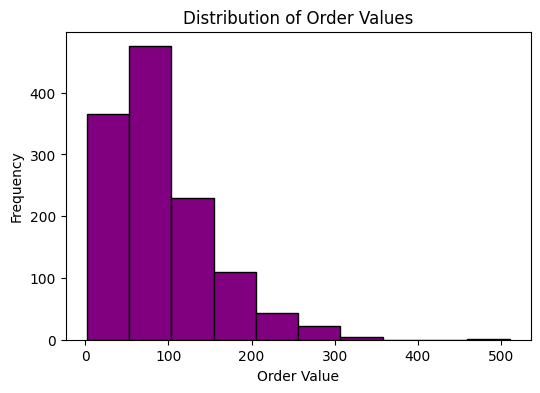

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(orders['order_value'], bins=10, color='purple', edgecolor='black')

plt.title("Distribution of Order Values")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.show()

CHART 2 — SCATTER PLOT (Distance vs Cost)

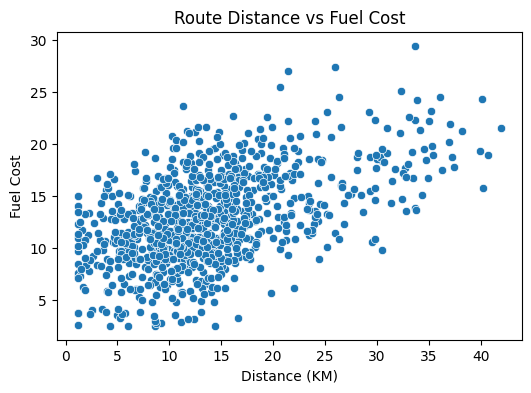

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=deliveries,
    x="route_distance_km",
    y="fuel_or_charge_cost"
)

plt.title("Route Distance vs Fuel Cost")
plt.xlabel("Distance (KM)")
plt.ylabel("Fuel Cost")

plt.show()

CHART 3 — BOX PLOT (Delivery Ratings)

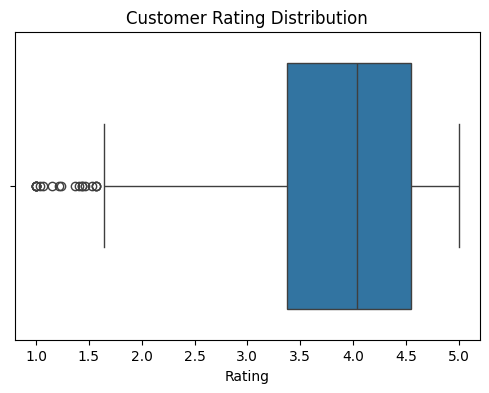

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=deliveries['customer_rating_post_delivery'])

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")

plt.show()

CHART 4 — HEATMAP (CORRELATION)

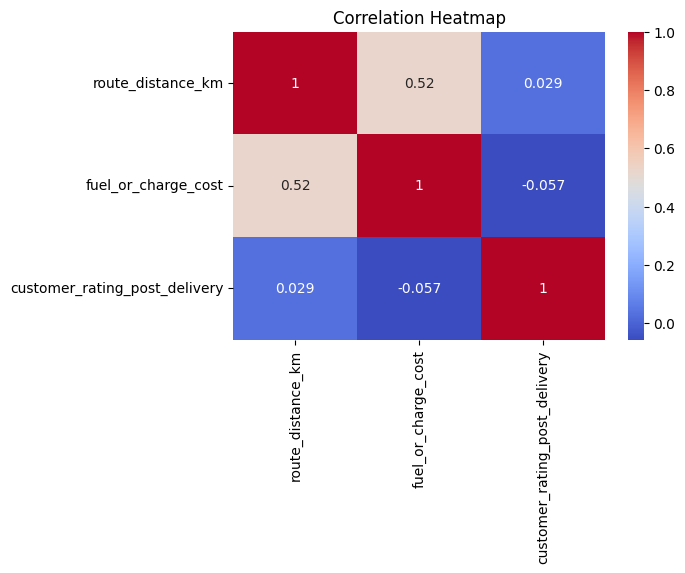

In [ ]:
plt.figure(figsize=(6,4))

corr = deliveries[['route_distance_km',
                   'fuel_or_charge_cost',
                   'customer_rating_post_delivery']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

CHART 5 - PAIRPLOT

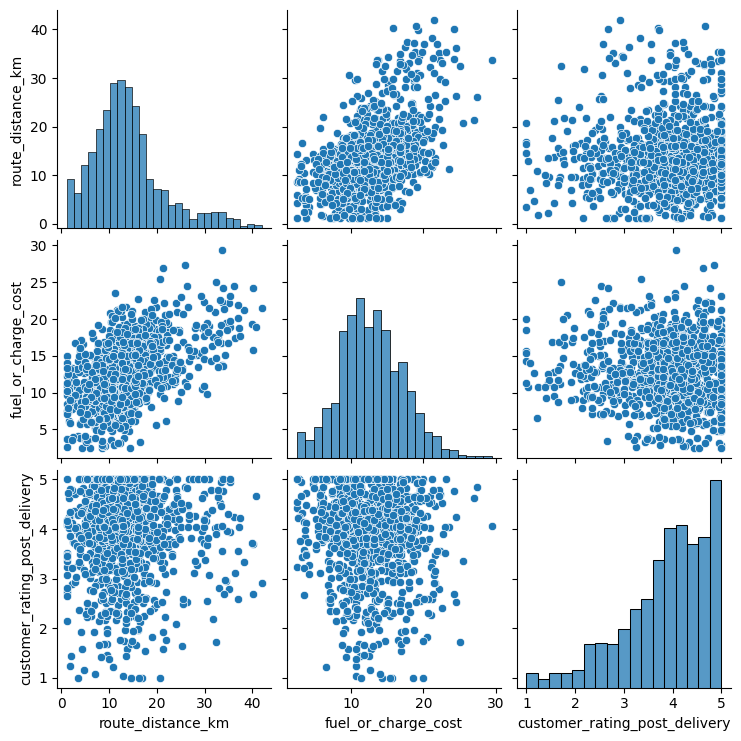

In [ ]:
sns.pairplot(deliveries[[
    'route_distance_km',
    'fuel_or_charge_cost',
    'customer_rating_post_delivery'
]])

plt.show()

CHART 6 - BAR CHART

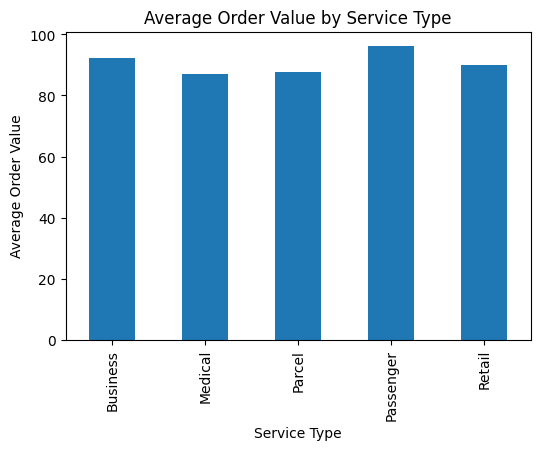

In [ ]:
plt.figure(figsize=(6,4))

orders.groupby('service_type')['order_value'].mean().plot(kind='bar')

plt.title("Average Order Value by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Order Value")

plt.show()